**Goal.** Evaluate 1-4‑steps forecasts on the ROI.

**What this notebook does**
1. Loads a trained checkpoint and the `GraphWeatherDataModule` for the validation years.
2. Runs 4‑step inference; computes **MAE/RMSE** per variable on the ROI.

**Recommended metrics & displays**
- Per‑variable MAE/RMSE at lead‑1 (Tout = 1).
- For AR rollouts: curves vs lead time for `t2m`, `u10`, `v10`, `msl`, `tp_log`.
- Spatial error maps and histograms for `tp`.

In [ ]:
import os, math, json, warnings
from pathlib import Path
from datetime import datetime, timezone
from collections import defaultdict

import numpy as np
import torch
import pandas as pd
from tqdm import tqdm

USE_CARTOPY = False
if USE_CARTOPY:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

In [ ]:
from utils.unified_graph_weather_dataloader import GraphWeatherDataModule
from model.unified_graph_weather_model import UnifiedGraphWeatherGATLightning
from model.unified_graph_weather_model_uv10 import WindUV10Lightning
from model.unified_graph_weather_model_tp import PrecipTPLightning

In [ ]:
# ---------- ROI bounds (deg) ----------
ROI_LON_MIN, ROI_LON_MAX = -11.0, 2.0
ROI_LAT_MIN, ROI_LAT_MAX = 49.0, 59.0
ROI_EXTENT = (ROI_LON_MIN, ROI_LON_MAX, ROI_LAT_MIN, ROI_LAT_MAX)

# ---------- Paths ----------
SHARDS_ROOT      = "./data/shards_graph"      # graph_{YYYY-MM}.pt
STATIC_GRAPH_NPZ = "./data/graph/graph_static_from_stats_vgeo_aligned.npz"
STATIC_GRID_025  = "./data/static/025/geo_pos_static.npz"   # ROI 0.25°
STATS_025_NPZ    = "./data/stats/stats_025deg_1980_2013.npz"

# --- прапори та шляхи чекпойнтів
USE_WIND_UV10_MODEL = True
USE_TP_MODEL        = True

CHECKPOINT_PATH_GEN  = "./lightning_logs/graph_gat_unified_1step/version_1/checkpoints/graph-gat-epoch=11-val_loss=0.0789.ckpt"
CHECKPOINT_PATH_WIND = "./lightning_logs/graph_gat_wind_1step/version_2/checkpoints/graph-gat-epoch=02-val_loss=0.0572.ckpt"
CHECKPOINT_PATH_TP   = "./lightning_logs/graph_gat_precip_1step/version_1/checkpoints/graph-gat-tp-epoch=02-val_loss=0.1433.ckpt"

In [ ]:
# eval:
YEARS_EVAL   = range(2024, 2025)   # лише 2024
BATCH_SIZE   = 8
NUM_WORKERS  = 6
PIN_MEMORY   = True
PERSISTENT   = True
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PRECISION_AMP= True        # bfloat16 autocast
# DIFF_STEP    = 0

# Grid-метрики (IDW на ROI-сітку) — True/False
EVAL_ON_ROI_GRID = True

In [7]:
# ===== Utils: stats / denorm =====
def load_stats(npz_path: str):
    z = np.load(npz_path, allow_pickle=True)
    order = list(z["order"])
    if order and isinstance(order[0], (bytes, np.bytes_)):
        order = [o.decode("utf-8") for o in order]
    mu = z["mean"].astype(np.float32, copy=False)
    sd = z["std"].astype(np.float32, copy=False)
    sd[sd < 1e-6] = 1e-6
    return order, mu, sd

def stats_key_from_channel_name(ch: str) -> str:
    ch = str(ch)
    if "@" in ch:
        var, lvl = ch.split("@", 1)
        key = var if lvl == "sfc" else f"{var}_{lvl}"
    else:
        key = ch
    return "tp_log" if key == "tp" else key

def denorm_single_channel(name_or_ch, arr_norm, stats_order, mu, sd):
    key = stats_key_from_channel_name(name_or_ch)
    idx = stats_order.index(key)
    arr = arr_norm * sd[idx] + mu[idx]
    if key == "tp_log":
        arr = np.expm1(arr); np.maximum(arr, 0.0, out=arr)
    return arr

def _to_epoch_s(ts):
    if isinstance(ts, (int, np.integer)): return int(ts)
    if isinstance(ts, float): return int(round(ts))
    if isinstance(ts, np.datetime64): return int(ts.astype("datetime64[s]").astype("int64"))
    if isinstance(ts, str):
        try:
            dt = datetime.fromisoformat(ts.replace("Z","")).replace(tzinfo=timezone.utc)
        except ValueError:
            dt = datetime.strptime(ts, "%Y-%m-%d %H:%M").replace(tzinfo=timezone.utc)
        return int(dt.timestamp())
    raise TypeError(type(ts))

# ===== Static graph → ROI indices (без сабграфа) =====
def load_edge_index_base(static_graph_npz: str) -> np.ndarray:
    d = np.load(static_graph_npz, allow_pickle=True)
    if "edge_index_horiz_base" in d:
        ei = d["edge_index_horiz_base"]
        if ei.ndim == 2 and ei.shape[0] == 2: return ei.astype(np.int64, copy=False)
        if ei.ndim == 2 and ei.shape[1] == 2: return ei.T.astype(np.int64, copy=False)
        raise ValueError("edge_index_horiz_base must be [2,E] or [E,2]")
    if "edge_index_horiz" in d and "horiz_edge_ptr" in d:
        e_all = d["edge_index_horiz"]
        e_all = e_all if (e_all.ndim == 2 and e_all.shape[0] == 2) else e_all.T
        ptr = d["horiz_edge_ptr"].astype(np.int64)
        e0 = e_all[:, int(ptr[0]):int(ptr[1])]
        if "level_offsets" in d:
            off0 = int(np.asarray(d["level_offsets"])[0])
            if off0 != 0: e0 = e0 - off0
        return e0.astype(np.int64, copy=False)
    raise KeyError("Не знайдено базових горизонтальних ребер у статиці.")

def make_roi_indices(static_graph_npz: str,
                     lon_min, lon_max, lat_min, lat_max):
    d = np.load(static_graph_npz, allow_pickle=True)
    lon = d["coord_lon"].astype(np.float32, copy=False)
    lat = d["coord_lat"].astype(np.float32, copy=False)
    if lon.max() > 180.0:
        lon = ((lon + 180.0) % 360.0) - 180.0
    mask = (lon >= lon_min) & (lon <= lon_max) & (lat >= lat_min) & (lat <= lat_max)
    idx_roi = np.where(mask)[0]
    if idx_roi.size == 0:
        raise ValueError("ROI порожній для обраного статичного графа.")
    return idx_roi.astype(np.int64), lon, lat

idx_roi_full, lon_full, lat_full = make_roi_indices(
    STATIC_GRAPH_NPZ, ROI_LON_MIN, ROI_LON_MAX, ROI_LAT_MIN, ROI_LAT_MAX
)
E_base = load_edge_index_base(STATIC_GRAPH_NPZ).shape[1]
print(f"N_full={lon_full.size}, Eh_base={E_base}, N_roi={idx_roi_full.size}")

N_full=4227, Eh_base=24932, N_roi=1382


In [ ]:
# ===== DataModule =====
dm = GraphWeatherDataModule(
    shards_root_train=SHARDS_ROOT,
    shards_root_val=SHARDS_ROOT,
    years_train=YEARS_EVAL,
    years_val=YEARS_EVAL,
    static_graph_npz=STATIC_GRAPH_NPZ,
    force_tin_tout=None,
    dtype_out="float32",
    shuffle_within_file_train=True,
    shuffle_within_file_val=False,
    batch_size_train=BATCH_SIZE,
    batch_size_val=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT,
    device="cuda" if DEVICE.type=="cuda" else "cpu",
)
dm.setup()
print(f"Val   samples: {dm.val_samples}")
print(f"N_mesh={dm.N_mesh}, C={dm.C}, Tin={dm.Tin}, Tout={dm.Tout}")

Val   samples: 1404
N_mesh=4227, C=21, Tin=2, Tout=4


In [ ]:
# REad channel_order from any shard
def _maybe_decode_list(obj):
    if isinstance(obj, (list, tuple, np.ndarray)):
        out = [(x.decode("utf-8") if isinstance(x, (bytes, np.bytes_)) else str(x)) for x in obj]
        return out
    if isinstance(obj, str) and obj.strip().startswith("["):
        try: return [str(x) for x in json.loads(obj)]
        except Exception: return None
    return None

def _extract_channel_order_from_shard_dict(d: dict):
    for k in ("channel_names", "channels", "order", "channel_order"):
        if k in d:
            names = _maybe_decode_list(d[k])
            if names: return names
    if "meta" in d and isinstance(d["meta"], dict):
        m = d["meta"]
        if "channels" in m and isinstance(m["channels"], dict):
            if "order" in m["channels"]:
                names = _maybe_decode_list(m["channels"]["order"])
                if names: return names
    for k, v in d.items():
        names = _maybe_decode_list(v)
        if names and any("@" in s for s in names): return names
    return None

def read_channel_order_from_any_shard(root: str, year: int):
    root = Path(root)
    cand = sorted(p for p in root.glob("graph_*.pt") if p.name.startswith(f"graph_{year}-"))
    if not cand: raise FileNotFoundError(f"Немає граф-шардів для {year} у {root}")
    d = torch.load(cand[0], map_location="cpu")
    names = _extract_channel_order_from_shard_dict(d)
    if names is None: raise KeyError("Не вдалося знайти назви каналів у шарді.")
    return names

In [10]:
channel_order = read_channel_order_from_any_shard(SHARDS_ROOT, 2024)
dm.channel_order = channel_order
print("Channels:", channel_order[:8], "... (total:", len(channel_order), ")")

Tin, Tout, C, N_full = dm.Tin, dm.Tout, dm.C, dm.N_mesh
edge_index_base_full = dm.edge_index_base
assert edge_index_base_full is not None

Channels: ['t2m@sfc', 'd2m@sfc', 'msl@sfc', 'u10@sfc', 'v10@sfc', 'tp_log@sfc', 't@850', 'u@850'] ... (total: 21 )


In [ ]:
# ===== Channel indices =====
def _find_idx(name: str, order: list[str]) -> int:
    n = name.lower()
    order_low = [s.lower() for s in order]
    if n in order_low: return order_low.index(n)
    if n == "u10@sfc" and "u10" in order_low: return order_low.index("u10")
    if n == "v10@sfc" and "v10" in order_low: return order_low.index("v10")
    raise KeyError(f"Channel {name} not in order")

iu = _find_idx("u10@sfc", channel_order)
iv = _find_idx("v10@sfc", channel_order)

def _find_tp_idx(order: list[str]) -> int:
    low = [s.lower() for s in order]
    for cand in ("tp_log@sfc", "tp@sfc", "tp_log", "tp"):
        if cand in low: return low.index(cand)
    raise KeyError("TP channel not found in channel_order")

itp = _find_tp_idx(channel_order)

In [ ]:
# ===== Models initialization =====
#Always: general model
lit_gen = UnifiedGraphWeatherGATLightning(
    C=C, Tin=Tin, Tout=1,
    edge_index_base=edge_index_base_full, N_mesh=N_full,
    embed_dim=192, blocks=4, heads_v=4, heads_xy=4, attn_drop_xy=0.0,
    lr=3e-4, weight_decay=1e-4, loss="mse",
).to(DEVICE).eval()
ckpt_gen = torch.load(CHECKPOINT_PATH_GEN, map_location="cpu")
lit_gen.load_state_dict(ckpt_gen.get('state_dict', ckpt_gen), strict=False)

# Spec: wind (optional)
lit_uv = None
if USE_WIND_UV10_MODEL:
    lit_uv = WindUV10Lightning(
        C=C, Tin=Tin, Tout=1,
        edge_index_base=edge_index_base_full, N_mesh=N_full,
        embed_dim=192, blocks=4, heads_v=4, heads_xy=4, attn_drop_xy=0.0,
        lr=1e-3, weight_decay=1e-4,
        loss_components=1.0, loss_magnitude=0.0, loss_direction=0.0,
        robust_loss=False,
        chan_u_name="u10@sfc", chan_v_name="v10@sfc",
        channel_order=channel_order,
        diffusion_max_step=0,
    ).to(DEVICE).eval()
    ckpt_uv = torch.load(CHECKPOINT_PATH_WIND, map_location="cpu")
    lit_uv.load_state_dict(ckpt_uv.get("state_dict", ckpt_uv), strict=False)

# Spes: precip (optional)
lit_tp = None
if USE_TP_MODEL:
    lit_tp = PrecipTPLightning(
        C=C, Tin=Tin, Tout=1,
        edge_index_base=edge_index_base_full, N_mesh=N_full,
        embed_dim=192, blocks=4, heads_v=4, heads_xy=4, attn_drop_xy=0.0,
        lr=3e-4, weight_decay=1e-4,
        diffusion_max_step=0,
        channel_order=channel_order,
    ).to(DEVICE).eval()
    ckpt_tp = torch.load(CHECKPOINT_PATH_TP, map_location="cpu")
    lit_tp.load_state_dict(ckpt_tp.get("state_dict", ckpt_tp), strict=False)

In [ ]:
# ===== ROI grid (0.25°) =====
stats_order, mu_vec, sd_vec = load_stats(STATS_025_NPZ)
idx_roi_t = torch.from_numpy(idx_roi_full).to(device=DEVICE)

G = np.load(STATIC_GRID_025, allow_pickle=True)
lat2d_025 = G["lat2d"].astype(np.float32)
lon2d_025 = G["lon2d"].astype(np.float32)
if lon2d_025.max() > 180.0:
    lon2d_025 = ((lon2d_025 + 180.0) % 360.0) - 180.0

mask_roi_grid = (lon2d_025 >= ROI_LON_MIN) & (lon2d_025 <= ROI_LON_MAX) & \
                (lat2d_025 >= ROI_LAT_MIN) & (lat2d_025 <= ROI_LAT_MAX)
rows = np.where(mask_roi_grid.any(axis=1))[0]
cols = np.where(mask_roi_grid.any(axis=0))[0]
hs = slice(rows.min(), rows.max()+1)
ws = slice(cols.min(), cols.max()+1)
lonR = lon2d_025[hs, ws]; latR = lat2d_025[hs, ws]

In [14]:
def idw_grid_vectorized(lon_nodes, lat_nodes, vals_nodes, lon2d, lat2d, eps=1e-6):
    Lg = lon2d.reshape(-1).astype(np.float64)
    La = lat2d.reshape(-1).astype(np.float64)
    LN = lon_nodes.astype(np.float64)[:, None]
    LA = lat_nodes.astype(np.float64)[:, None]
    dx = LN - Lg[None, :]
    dy = LA - La[None, :]
    dist2 = dx*dx + dy*dy
    hit = dist2.min(axis=0)
    w = 1.0 / (dist2 + eps)
    num = (w * vals_nodes.astype(np.float64)[:, None]).sum(axis=0)
    den = w.sum(axis=0)
    out = (num / den).astype(np.float32)
    exact = hit < 1e-12
    if exact.any():
        jstar = dist2.argmin(axis=0)
        out[exact] = vals_nodes[jstar[exact]]
    return out.reshape(lon2d.shape)

In [ ]:
# ===== Metrics: seperate for k1..k4 on (graph ROI) and (ROI grid) =====
K = 4  # autoregressive steps
channels_eval = channel_order
acc = {
    "graph": {k: defaultdict(lambda: [0.0, 0.0, 0]) for k in range(1, K+1)},  # ch -> [sum_abs, sum_sq, count]
    "grid" : {k: defaultdict(lambda: [0.0, 0.0, 0]) for k in range(1, K+1)},
}

In [ ]:
# ===== Val dataloader / autocast =====
val_loader = dm.val_dataloader()
autocast_ctx = (torch.cuda.amp.autocast(dtype=torch.bfloat16)
                if (PRECISION_AMP and DEVICE.type=="cuda") else torch.no_grad())

C:\Users\andri\AppData\Local\Temp\ipykernel_15180\3636179226.py:3: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  autocast_ctx = (torch.cuda.amp.autocast(dtype=torch.bfloat16)


In [ ]:
# ===== Main eval loop =====
pbar = tqdm(val_loader, desc=f"Eval 2024 AR{K} (GEN{'+UV' if lit_uv else ''}{'+TP' if lit_tp else ''})", total=len(val_loader))
with torch.no_grad():
    for (x_all, geo, pos2d), y_all in pbar:
        # x_all: [B,Tin,C,N], y_all: [B,Tout,C,N]
        x_all = x_all.to(DEVICE, non_blocking=True)
        geo   = geo  .to(DEVICE, non_blocking=True)
        pos2d = pos2d.to(DEVICE, non_blocking=True)
        y_all = y_all.to(DEVICE, non_blocking=True)

        # checks
        assert y_all.dim() == 4, f"Очікую y_all як [B,Tout,C,N], маю {tuple(y_all.shape)}"
        K_GT = int(min(K, y_all.size(1)))

        x_roll = x_all.clone()
        B, TinB, CB, NB = x_roll.shape
        steps = torch.full((B,), float(DIFF_STEP), device=DEVICE)

        for k in range(1, K+1):
            with autocast_ctx:
                # 1) Full forecast from general model
                y_hat_full_gen = lit_gen.net((x_roll, geo, pos2d), diffusion_step=steps)  # [B,1,C,N]
                y_pred_full = y_hat_full_gen[:, 0]  # [B,C,N]

                # 2) UV, TP (if any)
                if lit_uv is not None:
                    y_hat_uv = lit_uv.net((x_roll, geo, pos2d), diffusion_step=steps, channel_order=channel_order)  # [B,1,2,N]
                    y_uv = y_hat_uv[:, 0]  # [B,2,N]
                    y_pred_full[:, iu] = y_uv[:, 0]
                    y_pred_full[:, iv] = y_uv[:, 1]

                if lit_tp is not None:
                    y_hat_tp = lit_tp.net((x_roll, geo, pos2d), diffusion_step=steps, channel_order=channel_order)  # [B,1,1,N] або [B,1,C?,N]
                    if y_hat_tp.size(2) == 1:
                        y_tp = y_hat_tp[:, 0, 0]  # [B,N]
                    else:
                        y_tp = y_hat_tp[:, 0, itp]  # in case multi-head
                    y_pred_full[:, itp] = y_tp

            # ---- ROI ----
            y_pred_roi = y_pred_full[..., idx_roi_t]  # [B,C,N_roi]

            # GT  if k ≤ K_GT
            use_gt = (k <= K_GT)
            y_true_full = y_all[:, k-1] if use_gt else None  # [B,C,N] або None

            # ---- metrics over channel ----
            for ch in channels_eval:
                ch_low = ch.lower()
                if ch_low in ("u10@sfc", "u10"): ch_idx = iu
                elif ch_low in ("v10@sfc", "v10"): ch_idx = iv
                elif ch_low in ("tp_log@sfc", "tp@sfc", "tp_log", "tp"): ch_idx = itp
                else:
                    try:
                        ch_idx = channel_order.index(ch)
                    except ValueError:
                        # case-insensitive
                        ch_idx = [s.lower() for s in channel_order].index(ch_low)

                pred_bn = y_pred_roi[:, ch_idx].detach().float().cpu().numpy()  # [B,N_roi]
                if not use_gt:
                    continue
                true_bn = y_true_full[..., idx_roi_t][:, ch_idx].detach().float().cpu().numpy()  # [B,N_roi]

                for b in range(pred_bn.shape[0]):
                    pred_b = pred_bn[b]  # [N_roi]
                    true_b = true_bn[b]  # [N_roi]

                    pred_dn = denorm_single_channel(ch, pred_b, stats_order, mu_vec, sd_vec)
                    true_dn = denorm_single_channel(ch, true_b, stats_order, mu_vec, sd_vec)

                    # --- граф-вузли ROI ---
                    diff = pred_dn - true_dn
                    m = np.isfinite(diff)
                    sa, ss, cnt = acc["graph"][k][ch]
                    acc["graph"][k][ch] = [
                        sa  + np.abs(diff[m]).sum(dtype=np.float64),
                        ss  + np.square(diff[m]).sum(dtype=np.float64),
                        cnt + int(m.sum()),
                    ]

                    # --- regular ROI-mesh 0.25° (IDW) ---
                    if EVAL_ON_ROI_GRID:
                        grid_pred = idw_grid_vectorized(
                            lon_full[idx_roi_full], lat_full[idx_roi_full], pred_dn, lonR, latR
                        )
                        grid_true = idw_grid_vectorized(
                            lon_full[idx_roi_full], lat_full[idx_roi_full], true_dn, lonR, latR
                        )
                        D = grid_pred - grid_true
                        m2 = np.isfinite(D)
                        sa, ss, cnt = acc["grid"][k][ch]
                        acc["grid"][k][ch] = [
                            sa  + np.abs(D[m2]).sum(dtype=np.float64),
                            ss  + np.square(D[m2]).sum(dtype=np.float64),
                            cnt + int(m2.sum()),
                        ]

            # ---- autoregresive move ----
            x_next = torch.empty_like(x_roll)
            x_next[:, :-1] = x_roll[:, 1:]
            # persistence as start
            x_next[:, -1]  = x_roll[:, -1]
            # …replace entire last frame with composite forecast
            x_next[:, -1]  = y_pred_full
            x_roll = x_next

Eval 2024 AR4 (GEN+UV+TP): 100%|██████████| 176/176 [2:06:57<00:00, 43.28s/it] 


In [ ]:
# ===== Table construction =====
def _rows_from_acc(bucket):
    rows = []
    for k in range(1, K+1):
        for ch, (sa, ss, cnt) in bucket[k].items():
            if cnt == 0:
                continue
            rows.append({
                "k": k, "channel": ch,
                "MAE": sa / cnt,
                "RMSE": math.sqrt(ss / cnt),
                "N": cnt
            })
    return pd.DataFrame(rows).sort_values(["channel", "k"]).reset_index(drop=True)

In [18]:
df_graph = _rows_from_acc(acc["graph"])
print("\n=== Metrics on ROI graph nodes (AR up to k=4, composed GEN+UV+TP) ===")
print(df_graph.to_string(index=False) if len(df_graph) else "No GT available beyond k=1 with current shards.")

if EVAL_ON_ROI_GRID:
    df_grid = _rows_from_acc(acc["grid"])
    print("\n=== Metrics on ROI regular 0.25° grid (IDW from graph, AR up to k=4, composed GEN+UV+TP) ===")
    print(df_grid.to_string(index=False) if len(df_grid) else "No GT available beyond k=1 with current shards.")


=== Metrics on ROI graph nodes (AR up to k=4, composed GEN+UV+TP) ===
 k    channel        MAE       RMSE       N
 1    d2m@sfc   0.705469   0.944924 1940328
 2    d2m@sfc   1.030633   1.366209 1940328
 3    d2m@sfc   1.277852   1.690375 1940328
 4    d2m@sfc   1.518103   2.020925 1940328
 1    msl@sfc  76.177511 102.969922 1940328
 2    msl@sfc 167.365245 228.891972 1940328
 3    msl@sfc 288.814947 396.591748 1940328
 4    msl@sfc 422.940931 570.594377 1940328
 1      r@300  13.780723  18.269096 1940328
 2      r@300  18.134227  23.145107 1940328
 3      r@300  21.659294  27.124926 1940328
 4      r@300  24.090946  29.827422 1940328
 1      r@500  13.592760  17.855524 1940328
 2      r@500  17.782625  22.501441 1940328
 3      r@500  21.173697  26.247929 1940328
 4      r@500  23.632266  28.933344 1940328
 1      r@850   8.844343  12.180338 1940328
 2      r@850  11.550893  15.573685 1940328
 3      r@850  13.404494  17.797010 1940328
 4      r@850  14.796848  19.467516 1940328
 1   

In [17]:
import numpy as np, torch, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

USE_CARTOPY = True
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAVE_CARTOPY = True
except Exception:
    HAVE_CARTOPY = False

# ---------- допоміжні: час / читання GT / пошук семпла ----------
from datetime import datetime, timezone
import json

In [ ]:
def _to_epoch_s(ts):
    if isinstance(ts, (int, np.integer)): return int(ts)
    if isinstance(ts, float): return int(round(ts))
    if isinstance(ts, np.datetime64): return int(ts.astype("datetime64[s]").astype("int64"))
    if isinstance(ts, str):
        try:
            dt = datetime.fromisoformat(ts.replace("Z","")).replace(tzinfo=timezone.utc)
        except ValueError:
            dt = datetime.strptime(ts, "%Y-%m-%d %H:%M").replace(tzinfo=timezone.utc)
        return int(dt.timestamp())
    raise TypeError(type(ts))

def _get_val_dataset(dm):
    if hasattr(dm, "val_set") and dm.val_set is not None: return dm.val_set
    if hasattr(dm, "_val_ds") and dm._val_ds is not None: return dm._val_ds
    return dm.val_dataloader().dataset

def _target_unix_from_shard_meta(d: dict, s_idx: int, lead: int = 1) -> int:
    t0 = int(d["t0_unix"]); dt = int(d["dt_seconds"]); Tin = int(d["Tin"]); stride = int(d.get("stride", 1))
    starts = np.asarray(d["sample_starts"], dtype=np.int64)
    base = int(starts[int(s_idx)] + Tin*stride + (lead-1)*stride)
    return int(t0 + base*dt)

def find_entry_by_timestamp_DM(dm, target_ts, lead=1):
    ds = _get_val_dataset(dm); tgt = _to_epoch_s(target_ts)
    for i, entry in enumerate(ds.entries):
        path, s_idx = entry if len(entry)==2 else (entry[0], entry[1])
        d = ds._load_shard(path)
        if _target_unix_from_shard_meta(d, int(s_idx), lead=lead) == tgt:
            return i
    raise ValueError("Не знайдено семпл за цим часом.")

def load_gt_multi_from_entry(ds, entry, leads=(1,2,3,4)):
    path, s_idx = entry
    d = ds._load_shard(path)
    vals   = d["values"]                 # [T,C,N] (np, torch)
    Tin    = int(d["Tin"])
    stride = int(d.get("stride", 1))
    starts = np.asarray(d["sample_starts"], dtype=np.int64)
    base   = int(starts[int(s_idx)] + Tin*stride)
    idxs   = [base + (L-1)*stride for L in leads]
    arr    = vals[idxs]                  # [L,C,N]
    if isinstance(arr, torch.Tensor): arr = arr.detach().cpu().numpy()
    return np.asarray(arr, dtype=np.float32)

# ---------- channel / stats ----------
def shard_channel_candidates_from_param(param: str) -> list[str]:
    p = str(param).strip().replace(" ", "")
    if "@" in p:
        v,l = p.split("@",1)
        return ["tp_log@sfc","tp_log"] if (v=="tp" and l.lower()=="sfc") else [f"{v}@{l}", f"{v}_{l}" if l.lower()!="sfc" else v]
    if "_" in p:
        v,l = p.split("_",1); return [f"{v}@{l}", f"{v}_{l}"]
    if p=="tp": return ["tp_log@sfc","tp_log"]
    if p=="tp_log": return ["tp_log@sfc","tp_log"]
    return [f"{p}@sfc", p]

def find_channel_index(channel_order: list[str], param: str) -> int:
    order = [str(x) for x in channel_order]; low = [x.lower() for x in order]
    for cand in shard_channel_candidates_from_param(param):
        if cand.lower() in low: return low.index(cand.lower())
    raise KeyError(f"'{param}' не знайдено у channel_order")

def stats_key_from_channel_name(ch: str) -> str:
    if "@" in ch:
        var,lvl = ch.split("@",1)
        key = var if lvl=="sfc" else f"{var}_{lvl}"
    else:
        key = ch
    return "tp_log" if key=="tp" else key

def load_stats(npz_path: str):
    z = np.load(npz_path, allow_pickle=True)
    order = list(z["order"])
    if order and isinstance(order[0], (bytes, np.bytes_)):
        order = [o.decode("utf-8") for o in order]
    mu = z["mean"].astype(np.float32); sd = z["std"].astype(np.float32); sd[sd<1e-6]=1e-6
    return order, mu, sd

def denorm_single_channel(name_or_ch, arr_norm, stats_order, mu, sd):
    key = stats_key_from_channel_name(str(name_or_ch))
    idx = stats_order.index(key)
    arr = arr_norm * sd[idx] + mu[idx]
    if key == "tp_log":
        arr = np.expm1(arr); np.maximum(arr, 0.0, out=arr)
    return arr

# ---------- ROI grid і IDW ----------
def load_roi_grid(static_025_npz: str, lon_min, lon_max, lat_min, lat_max):
    d = np.load(static_025_npz, allow_pickle=True)
    lat2d = d["lat2d"].astype(np.float32); lon2d = d["lon2d"].astype(np.float32)
    if lon2d.max() > 180.0: lon2d = ((lon2d + 180.0) % 360.0) - 180.0
    m = (lat2d >= lat_min) & (lat2d <= lat_max) & (lon2d >= lon_min) & (lon2d <= lon_max)
    rows = np.where(m.any(axis=1))[0]; cols = np.where(m.any(axis=0))[0]
    hs, ws = slice(rows.min(), rows.max()+1), slice(cols.min(), cols.max()+1)
    return lat2d[hs, ws], lon2d[hs, ws]

def idw_grid_vectorized(lon_src, lat_src, val_src, lon2d, lat2d, k=8, eps=1e-6, p=2.0, chunk=4096):
    src = np.c_[lon_src.astype(np.float64), lat_src.astype(np.float64)]
    vals = val_src.astype(np.float64)
    Gx = lon2d.astype(np.float64).ravel(); Gy = lat2d.astype(np.float64).ravel()
    M, N = Gx.size, src.shape[0]
    out = np.full(M, np.nan, dtype=np.float64)
    k = max(1, min(int(k), N))
    for i0 in range(0, M, chunk):
        i1 = min(M, i0+chunk)
        gx = Gx[i0:i1][:, None]; gy = Gy[i0:i1][:, None]

        dx = src[None,:,0] - gx; dy = src[None,:,1] - gy
        D = np.hypot(dx, dy)                            # [Q,N]
        exact = (D <= eps)
        any_exact = exact.any(axis=1)
        if any_exact.any():
            rows = np.where(any_exact)[0]
            for r in rows:
                j = np.where(exact[r])[0][0]
                out[i0 + r] = float(vals[j])
        rem = ~any_exact
        if rem.any():
            Drem = D[rem]
            idx = np.argpartition(Drem, kth=k-1, axis=1)[:, :k]
            dsel = np.take_along_axis(Drem, idx, axis=1)
            vsel = vals[idx]
            w = 1.0 / np.maximum(dsel, eps)**p
            wsum = w.sum(axis=1, keepdims=True)
            out[i0:i0+rem.sum()] = (np.sum(w*vsel, axis=1) / wsum[:,0])
    return out.reshape(lon2d.shape).astype(np.float32)

def _new_map_ax_cartopy(pos, title, extent):
    ax = plt.subplot(1, 2, pos, projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution="50m", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.4, edgecolor="black", alpha=0.6)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--", alpha=0.4)
    try:
        gl.top_labels = False; gl.right_labels = False
    except Exception:
        pass
    ax.set_title(title)
    return ax


In [ ]:
# ---------- AR GEN + (UV/TP overrides) ----------
@torch.no_grad()
def compose_rollout_autoregressive_K(lit_gen, x_all, geo, pos2d, steps, K,
                                     channel_order, lit_uv=None, lit_tp=None):
    """
    Повертає [B,K,C,N] — autoregresive forecast with replace UV/TP channels.
    """
    device = x_all.device
    B, Tin, C, N = x_all.shape
    x_roll = x_all.clone()
    preds = []

    iu = find_channel_index(channel_order, "u10")
    iv = find_channel_index(channel_order, "v10")
    try:
        itp = find_channel_index(channel_order, "tp_log")
    except Exception:
        itp = find_channel_index(channel_order, "tp")

    for _ in range(K):
        # 1) базовий прогноз (усі канали)
        y_gen = lit_gen.net((x_roll, geo, pos2d), diffusion_step=steps)[:, 0]  # [B,C,N]
        y_full = y_gen

        # 2) перезаписати UV/TP (якщо є)
        if lit_uv is not None:
            y_uv = lit_uv.net((x_roll, geo, pos2d), diffusion_step=steps, channel_order=channel_order)[:, 0]  # [B,2,N]
            y_full[:, iu] = y_uv[:, 0]; y_full[:, iv] = y_uv[:, 1]
        if lit_tp is not None:
            y_tp = lit_tp.net((x_roll, geo, pos2d), diffusion_step=steps, channel_order=channel_order)[:, 0]  # [B,?,N]
            if y_tp.size(1) == 1:
                y_full[:, itp] = y_tp[:, 0]
            else:
                y_full[:, itp] = y_tp[:, itp]  # на випадок multi-head

        preds.append(y_full)

        # 3) AR-зсув
        x_next = torch.empty_like(x_roll)
        x_next[:, :-1] = x_roll[:, 1:]
        x_next[:, -1]  = y_full
        x_roll = x_next

    return torch.stack(preds, dim=1)  # [B,K,C,N]

In [51]:
@torch.no_grad()
def animate_compose_ar(dm,
                       lit_gen,
                       timestamp,
                       param="u10",
                       view="grid",      # "grid" | "graph"
                       K=4,
                       DIFF_STEP=0.0,
                       lit_uv=None,
                       lit_tp=None,
                       static_grid_025="./data/static/025/geo_pos_static.npz",
                       static_graph_npz=None,
                       stats_npz="./data/stats/stats_025deg_1980_2013.npz",
                       channel_order=None,
                       ROI_LON_MIN=ROI_LON_MIN, ROI_LON_MAX=ROI_LON_MAX,
                       ROI_LAT_MIN=ROI_LAT_MIN, ROI_LAT_MAX=ROI_LAT_MAX):
    device = next(lit_gen.parameters()).device
    ds = _get_val_dataset(dm)

    # індекс (lead-1 == timestamp)
    idx = find_entry_by_timestamp_DM(dm, timestamp, lead=1)
    (x_all, geo, pos2d), y_all = ds[idx]     # x:[Tin,C,N], y:[Tout,C,N]
    x_all = x_all.unsqueeze(0).to(device)
    geo   = geo  .unsqueeze(0).to(device)
    pos2d = pos2d.unsqueeze(0).to(device)
    y_all = y_all.unsqueeze(0).to(device)

    # channel_order: пріоритетно беремо із dm
    if channel_order is None:
        if hasattr(dm, "channel_order") and dm.channel_order is not None:
            channel_order = dm.channel_order
        else:
            chn = getattr(ds, "channel_names", None)
            if chn is None:
                raise RuntimeError("Немає channel_order: передай явно або ініціалізуй dm.channel_order")
            if isinstance(chn, (bytes, np.bytes_)): chn = chn.decode("utf-8", errors="ignore")
            if isinstance(chn, str):
                try: chn = json.loads(chn)
                except Exception: chn = [s.strip(" '\"") for s in chn.strip("[]").split(",")]
            channel_order = [s.decode("utf-8") if isinstance(s, (bytes, np.bytes_)) else str(s) for s in chn]

    # координати вузлів із статики
    sg_path = static_graph_npz or getattr(dm, "static_graph_npz", None) \
              or "./data/graph/graph_static_from_stats_vgeo_aligned.npz"
    Gs = np.load(sg_path, allow_pickle=True)
    lon_nodes = Gs["coord_lon"].astype(np.float32)
    lat_nodes = Gs["coord_lat"].astype(np.float32)
    lon_nodes = ((lon_nodes + 180.0) % 360.0) - 180.0

    # статистика
    stats_order, mu_vec, sd_vec = load_stats(stats_npz)

    # AR-роллаут (композиція)
    steps_vec = torch.full((1,), float(DIFF_STEP), device=device)
    y_predK = compose_rollout_autoregressive_K(lit_gen, x_all, geo, pos2d, steps_vec, K,
                                               channel_order, lit_uv=lit_uv, lit_tp=lit_tp)  # [1,K,C,N]

    # GT з шарду на K ефективних кроків (скільки є у файлі)
    entry = ds.entries[idx]
    K_eff = min(K, y_all.size(1))
    y_trueK = load_gt_multi_from_entry(ds, entry, leads=tuple(range(1, K_eff+1)))  # [K_eff,C,N]

    # обраний канал
    ci = find_channel_index(channel_order, param)
    ch_name = channel_order[ci]

    # денорм по всьому графу (без ROI обрізання!)
    pred_np = y_predK[0, :K_eff, ci].detach().float().cpu().numpy()  # [K_eff,N]
    true_np = y_trueK[:,          ci]                                # [K_eff,N]
    pred_dn = np.stack([denorm_single_channel(ch_name, pred_np[L], stats_order, mu_vec, sd_vec) for L in range(K_eff)], axis=0)
    true_dn = np.stack([denorm_single_channel(ch_name, true_np[L], stats_order, mu_vec, sd_vec) for L in range(K_eff)], axis=0)

    # ---------------- Graph режим: ПОВНИЙ ГРАФ ----------------
    if view == "graph":
        vmin = float(np.nanmin([pred_dn.min(), true_dn.min()]))
        vmax = float(np.nanmax([pred_dn.max(), true_dn.max()]))
        extent = (float(lon_nodes.min()), float(lon_nodes.max()),
                  float(lat_nodes.min()), float(lat_nodes.max()))

        fig = plt.figure(figsize=(12,5))
        if HAVE_CARTOPY and USE_CARTOPY:
            ax1 = _new_map_ax_cartopy(1, f"GT {param} (lead=1)", extent)
            sc1 = ax1.scatter(lon_nodes, lat_nodes, c=true_dn[0], s=10, cmap="viridis",
                              vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
            ax2 = _new_map_ax_cartopy(2, f"Pred {param} (lead=1)", extent)
            sc2 = ax2.scatter(lon_nodes, lat_nodes, c=pred_dn[0], s=10, cmap="viridis",
                              vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
            plt.colorbar(sc1, ax=ax1, fraction=0.046, pad=0.04)
            plt.colorbar(sc2, ax=ax2, fraction=0.046, pad=0.04)
        else:
            ax1 = plt.subplot(1,2,1); ax1.set_title(f"GT {param} (lead=1)")
            sc1 = ax1.scatter(lon_nodes, lat_nodes, c=true_dn[0], s=10, cmap="viridis", vmin=vmin, vmax=vmax)
            plt.colorbar(sc1, ax=ax1, fraction=0.046, pad=0.04)
            ax2 = plt.subplot(1,2,2); ax2.set_title(f"Pred {param} (lead=1)")
            sc2 = ax2.scatter(lon_nodes, lat_nodes, c=pred_dn[0], s=10, cmap="viridis", vmin=vmin, vmax=vmax)
            plt.colorbar(sc2, ax=ax2, fraction=0.046, pad=0.04)

        def update(frame):
            ax1.set_title(f"GT {param} (lead={frame+1})")
            ax2.set_title(f"Pred {param} (lead={frame+1})")
            sc1.set_array(true_dn[frame])
            sc2.set_array(pred_dn[frame])
            return sc1, sc2

        anim = FuncAnimation(fig, update, frames=K_eff, interval=700, blit=False)
        plt.tight_layout(); plt.show()
        return anim

    # ---------------- Grid режим: ROI 0.25° (IDW) ----------------
    latR, lonR = load_roi_grid(static_grid_025, ROI_LON_MIN, ROI_LON_MAX, ROI_LAT_MIN, ROI_LAT_MAX)
    lonR = ((lonR + 180.0) % 360.0) - 180.0

    # ROI-маска тільки для GRID (вибираємо вузли в межах ROI)
    m_roi = (lon_nodes >= ROI_LON_MIN) & (lon_nodes <= ROI_LON_MAX) & \
            (lat_nodes >= ROI_LAT_MIN) & (lat_nodes <= ROI_LAT_MAX)
    if not np.any(m_roi):
        raise RuntimeError("У межах ROI немає вузлів графа.")
    lon_roi_nodes = lon_nodes[m_roi]; lat_roi_nodes = lat_nodes[m_roi]

    pred_grids, true_grids = [], []
    for L in range(K_eff):
        pred_grids.append(idw_grid_vectorized(lon_roi_nodes, lat_roi_nodes, pred_dn[L, m_roi], lonR, latR))
        true_grids.append(idw_grid_vectorized(lon_roi_nodes, lat_roi_nodes, true_dn[L, m_roi], lonR, latR))
    pred_grids = np.asarray(pred_grids); true_grids = np.asarray(true_grids)

    vmin = float(np.nanmin([pred_grids.min(), true_grids.min()]))
    vmax = float(np.nanmax([pred_grids.max(), true_grids.max()]))
    extent_roi = (float(lonR.min()), float(lonR.max()), float(latR.min()), float(latR.max()))

    fig = plt.figure(figsize=(12,5))
    if HAVE_CARTOPY and USE_CARTOPY:
        ax1 = _new_map_ax_cartopy(1, f"GT {param} (lead=1)", extent_roi)
        im1 = ax1.imshow(true_grids[0], origin="lower", extent=extent_roi, transform=ccrs.PlateCarree(),
                         vmin=vmin, vmax=vmax, cmap="viridis")
        ax2 = _new_map_ax_cartopy(2, f"Pred {param} (lead=1)", extent_roi)
        im2 = ax2.imshow(pred_grids[0], origin="lower", extent=extent_roi, transform=ccrs.PlateCarree(),
                         vmin=vmin, vmax=vmax, cmap="viridis")
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    else:
        ax1 = plt.subplot(1,2,1); ax1.set_title(f"GT {param} (lead=1)")
        im1 = ax1.imshow(true_grids[0], origin="lower", extent=extent_roi, vmin=vmin, vmax=vmax, cmap="viridis")
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        ax2 = plt.subplot(1,2,2); ax2.set_title(f"Pred {param} (lead=1)")
        im2 = ax2.imshow(pred_grids[0], origin="lower", extent=extent_roi, vmin=vmin, vmax=vmax, cmap="viridis")
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    def update(frame):
        ax1.set_title(f"GT {param} (lead={frame+1})")
        ax2.set_title(f"Pred {param} (lead={frame+1})")
        im1.set_data(true_grids[frame])
        im2.set_data(pred_grids[frame])
        return im1, im2

    anim = FuncAnimation(fig, update, frames=K_eff, interval=700, blit=False)
    plt.tight_layout(); plt.show()
    return anim

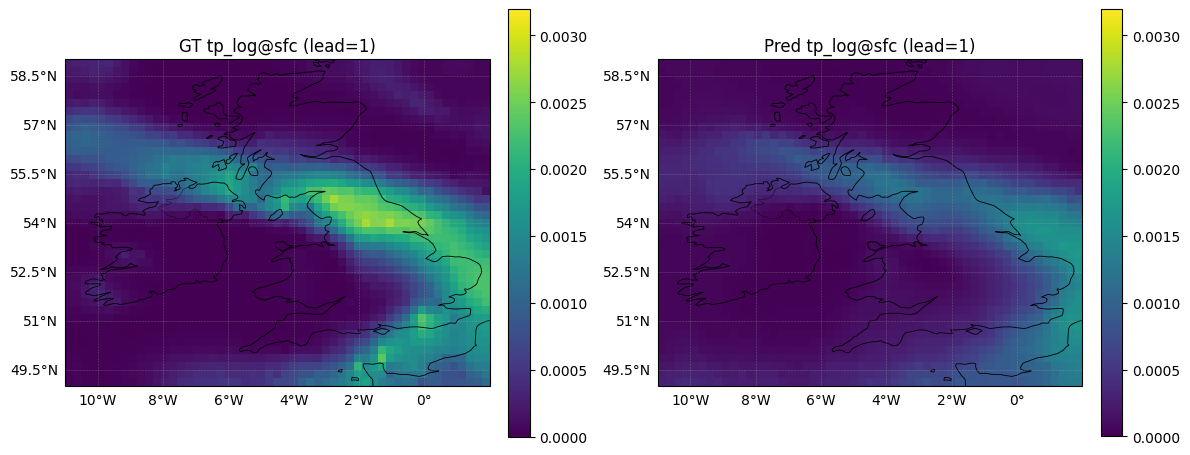

In [39]:
anim = animate_compose_ar(
    dm,
    lit_gen=lit_gen,
    lit_uv=lit_uv,          # або None
    lit_tp=lit_tp,          # або None
    timestamp="2024-01-02 00:00",
    param="tp_log@sfc", # "u10" "v10" "tp" "tp_log@sfc"
    view="grid",           # ← повний граф без ROI обрізання; спробуй також "grid" "graph"
    K=4,
    DIFF_STEP=0.0,
    channel_order=dm.channel_order,
    static_graph_npz=getattr(dm, "static_graph_npz", "./data/graph/graph_static_from_stats_vgeo_aligned.npz"),
    static_grid_025="./data/static/025/geo_pos_static.npz"
)

In [40]:
HTML(anim.to_jshtml())